# Topic 3 — Time-based Features
**Covers:** Lag features (single & multiple) · Rolling mean/std/min/max/median · Expanding
windows · Cyclical encoding (sin/cos) · Seasonality extraction · Seasonal decomposition ·
Trend features · Differencing · Handling NaNs from time-window features · Correct
train/test splitting for time series (no leakage)

**Dataset:** `data/raw/daily_enrollments.csv` — PrepEdge institute's daily new-enrollment
counts over ~2.5 years, built with a genuine upward trend, weekly seasonality (weekend bumps),
and yearly seasonality (admission-season spike) — so every feature type below captures a real
pattern, not decoration.

---
## Explanation

Imagine you keep a diary of how many candies you ate every day.

- **Lag feature** = looking at YESTERDAY's page (or last week's page) to help guess today
  ("yesterday I ate 5, so today's probably close to 5 too").
- **Rolling mean/std/min/max/median** = instead of one single day, look at the last 7 days as
  a group: the AVERAGE candy count, how MUCH it bounced around, the WORST day, the BEST day,
  and the MIDDLE-most day — five different ways to summarize "recently."
- **Expanding window** = keeping a running total/average from the very first day of your diary
  until today — it only grows, it never "forgets" old days.
- **Cyclical encoding (sin/cos)** = a clock's hands go in a circle — 11 PM and 1 AM are close
  together in real life, even though as plain numbers (23 and 1) they look far apart! We draw
  time on a circle so the model understands "midnight wraps back around."
- **Seasonality** = candies you eat go up every Halloween and every birthday — a repeating
  pattern the calendar creates.
- **Seasonal decomposition** = a machine that automatically splits your diary into THREE neat
  piles: "the slow growing-up trend," "the repeating Halloween pattern," and "just random
  leftover noise" — so you can look at each piece separately.
- **Trend** = are you generally eating more candies each month as you get older — the slow,
  long-term direction, ignoring the day-to-day ups and downs.
- **Differencing** = instead of writing down HOW MANY candies you ate, write down how many
  MORE (or fewer) than yesterday — this removes the slow growing-up trend and leaves just the
  interesting ups and downs.
- **Correct train/test split** = you can only use OLD diary pages to guess FUTURE ones — never
  peek at tomorrow's page to help guess today's number, even by accident!

## 1. WHY — Why do time-based features need special treatment?

A plain `date` column, on its own, is useless to a model (Unit 1, Session 1/3). But time
carries THREE distinct kinds of signal that a model can't discover on its own from one row:
1. **What happened recently** (lag, rolling stats) — the near-past predicts the near-future.
2. **Repeating patterns** (seasonality, cyclical encoding) — Mondays differ from Saturdays,
   January differs from June, in a way that repeats forever.
3. **Long-term direction** (trend) — is the underlying series generally rising or falling,
   independent of the day-to-day noise?

Without engineering these explicitly, a row-by-row model (which doesn't see other rows) has
literally no way to know any of this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/daily_enrollments.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()

(900, 2)


,date,new_enrollments
0,2024-01-01,13
1,2024-01-02,18
2,2024-01-03,5
3,2024-01-04,19
4,2024-01-05,12


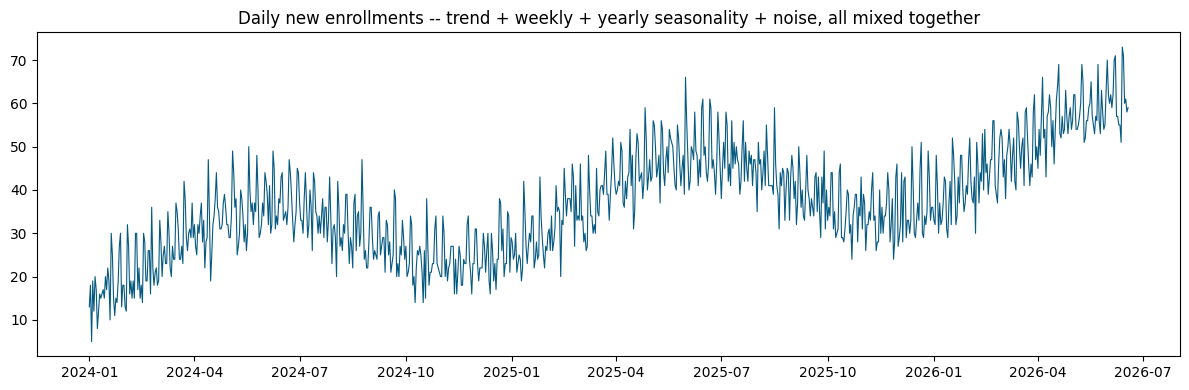

In [2]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["new_enrollments"], color="#065A82", linewidth=0.8)
plt.title("Daily new enrollments -- trend + weekly + yearly seasonality + noise, all mixed together")
plt.tight_layout()
plt.show()

## 2. Lag features — WHY / WHAT / HOW

**Why:** yesterday's enrollment count is one of the single best predictors of today's — recent
history carries momentum. But different lags capture different rhythms: `lag_1` catches
day-to-day momentum, `lag_7` catches "same weekday last week" (since our data has a weekly
cycle), and `lag_30` catches "roughly a month ago."

**Manual example.** Suppose the last 5 days were `[10, 14, 9, 20, 16]` (today is the 5th day,
value 16). `lag_1` (yesterday) = `20`. `lag_2` (2 days ago) = `9`.

In [3]:
df["lag_1"] = df["new_enrollments"].shift(1)      # yesterday's value
df["lag_7"] = df["new_enrollments"].shift(7)      # same day, last week (captures weekly rhythm)
df["lag_30"] = df["new_enrollments"].shift(30)    # roughly a month ago (captures slower drift)

df[["date", "new_enrollments", "lag_1", "lag_7", "lag_30"]].iloc[28:35]

,date,new_enrollments,lag_1,lag_7,lag_30
28,2024-01-29,13,30.0,15.0,NaN
29,2024-01-30,18,13.0,11.0,NaN
30,2024-01-31,18,18.0,15.0,13.0
31,2024-02-01,13,18.0,14.0,18.0
32,2024-02-02,12,13.0,19.0,5.0
33,2024-02-03,32,12.0,27.0,19.0
34,2024-02-04,27,32.0,30.0,12.0


**Which lag actually helps?** Let's check correlation of each lag with the current value —
a quick, cheap way to decide which lags are worth keeping as features (this is effectively an
autocorrelation check).

In [4]:
for lag_col in ["lag_1", "lag_7", "lag_30"]:
    valid = df[["new_enrollments", lag_col]].dropna()
    corr = valid["new_enrollments"].corr(valid[lag_col])
    print(f"Correlation(today, {lag_col}): {corr:.3f}")

Correlation(today, lag_1): 0.804
Correlation(today, lag_7): 0.893
Correlation(today, lag_30): 0.657


`lag_1` and `lag_7` should both show a meaningfully positive correlation (yesterday, and
"this day last week," both carry real signal in our weekly-seasonal data) — `lag_30` is
typically weaker, since a full month is far enough back that daily noise has mostly washed out
any specific predictive link, though the slow trend still keeps it mildly positive.

## 3. Rolling statistics: mean, std, min, max, median — WHY / WHAT / HOW

**Why:** a single day can be noisy (one canceled batch, one public holiday). A rolling window
summarizes several kinds of "what's been happening recently," each answering a different
question:
- **mean** — what's the typical/central level recently?
- **std** — how volatile/unstable has it been recently?
- **min / max** — what's the worst/best day recently? (Useful for spotting anomalies.)
- **median** — a center that's robust to a single extreme day (unlike the mean).

**Manual example.** 7-day rolling mean ending today, with the last 7 values
`[10, 14, 9, 20, 16, 13, 17]`:
```
mean   = (10+14+9+20+16+13+17) / 7 = 99 / 7 = 14.14
sorted = [9, 10, 13, 14, 16, 17, 20]  ->  median (middle of 7) = 14
min = 9, max = 20
```

In [5]:
toy_week = pd.Series([10, 14, 9, 20, 16, 13, 17])
print("Manual 7-day mean:  ", toy_week.mean().round(2))
print("Manual 7-day median:", toy_week.median())
print("Manual 7-day min/max:", toy_week.min(), "/", toy_week.max())

df["rolling_mean_7"] = df["new_enrollments"].rolling(window=7).mean()
df["rolling_std_7"] = df["new_enrollments"].rolling(window=7).std()
df["rolling_min_7"] = df["new_enrollments"].rolling(window=7).min()
df["rolling_max_7"] = df["new_enrollments"].rolling(window=7).max()
df["rolling_median_7"] = df["new_enrollments"].rolling(window=7).median()

df[["date", "new_enrollments", "rolling_mean_7", "rolling_median_7",
    "rolling_std_7", "rolling_min_7", "rolling_max_7"]].iloc[5:12]

Manual 7-day mean:   14.14
Manual 7-day median: 14.0
Manual 7-day min/max: 9 / 20


,date,new_enrollments,rolling_mean_7,rolling_median_7,rolling_std_7,rolling_min_7,rolling_max_7
5,2024-01-06,20,NaN,NaN,NaN,NaN,NaN
6,2024-01-07,17,14.857143,17.0,5.273474,5.0,20.0
7,2024-01-08,8,14.142857,17.0,5.871643,5.0,20.0
8,2024-01-09,12,13.285714,12.0,5.648430,5.0,20.0
9,2024-01-10,16,14.857143,16.0,4.336995,8.0,20.0
10,2024-01-11,15,14.285714,15.0,3.946065,8.0,20.0
11,2024-01-12,16,14.857143,16.0,3.848314,8.0,20.0


**When median beats mean:** if one day in the window had a data-entry glitch (e.g. a
one-off spike of 200 enrollments from a bug), the rolling MEAN would be dragged upward for the
next 7 days as that glitch slides through the window, while the rolling MEDIAN would barely
move — the median ignores single extreme values much better than the mean does.

## 4. Expanding window — WHY / WHAT / HOW

**Why:** sometimes you want "everything we've seen so far" rather than a fixed recent window —
e.g., the institute's all-time average enrollment rate, updated day by day, useful as a stable
long-run baseline to compare today against.

In [6]:
df["expanding_mean"] = df["new_enrollments"].expanding(min_periods=1).mean()
df[["date", "new_enrollments", "expanding_mean"]].iloc[[0, 1, 2, 50, 200, 500, 899]]

,date,new_enrollments,expanding_mean
0,2024-01-01,13,13.000000
1,2024-01-02,18,15.500000
2,2024-01-03,5,12.000000
50,2024-02-20,19,18.352941
200,2024-07-19,30,29.169154
500,2025-05-15,50,30.495010
899,2026-06-18,59,36.932222


Notice `expanding_mean` barely moves after day ~200 — with enough history, one more day
changes a running average less and less. That stability is exactly why it's useful as a baseline.

## 5. Cyclical encoding (sin/cos) — WHY / WHAT / HOW

**Why:** `day_of_week` as a plain number (`Mon=0 ... Sun=6`) tells a model that Sunday (6) and
Monday (0) are FAR apart (distance 6), when really they're ADJACENT days. Sin/cos encoding
places the 7 days on a circle, so Sunday and Monday end up close together, exactly as they
should be.

**Manual example.** For day-of-week `d` (0-6), with period `P = 7`:
```
sin_feature = sin(2*pi*d / 7)
cos_feature = cos(2*pi*d / 7)

Monday    (d=0): sin=0.000,  cos=1.000
Wednesday (d=2): sin=0.975,  cos=-0.223
Sunday    (d=6): sin=-0.782, cos=0.623
```
Notice Sunday (d=6) and Monday (d=0) land close together on the (sin, cos) circle, even though
6 and 0 look maximally far apart as plain numbers.

In [7]:
import math

for d, name in [(0, "Monday"), (2, "Wednesday"), (6, "Sunday")]:
    s, cval = math.sin(2 * math.pi * d / 7), math.cos(2 * math.pi * d / 7)
    print(f"{name:10s} (d={d}) -> sin={s:.3f}, cos={cval:.3f}")

df["day_of_week"] = df["date"].dt.dayofweek
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df[["date", "day_of_week", "dow_sin", "dow_cos"]].head(8)

Monday     (d=0) -> sin=0.000, cos=1.000
Wednesday  (d=2) -> sin=0.975, cos=-0.223
Sunday     (d=6) -> sin=-0.782, cos=0.623


,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.000000,1.000000
1,2024-01-02,1,0.781831,0.623490
2,2024-01-03,2,0.974928,-0.222521
3,2024-01-04,3,0.433884,-0.900969
4,2024-01-05,4,-0.433884,-0.900969
5,2024-01-06,5,-0.974928,-0.222521
6,2024-01-07,6,-0.781831,0.623490
7,2024-01-08,0,0.000000,1.000000


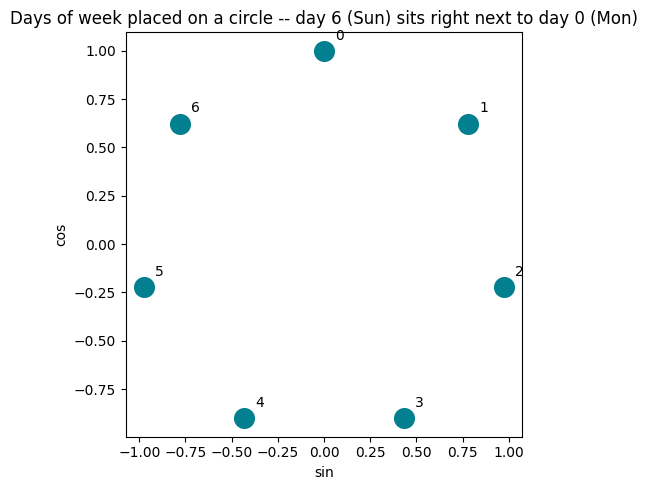

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
week = df.drop_duplicates("day_of_week").sort_values("day_of_week")
ax.scatter(week["dow_sin"], week["dow_cos"], s=200, color="#028090")
for _, row in week.iterrows():
    ax.annotate(int(row["day_of_week"]), (row["dow_sin"], row["dow_cos"]),
                textcoords="offset points", xytext=(8, 8))
ax.set_title("Days of week placed on a circle -- day 6 (Sun) sits right next to day 0 (Mon)")
ax.set_xlabel("sin"); ax.set_ylabel("cos")
plt.tight_layout()
plt.show()

## 6. Seasonality extraction — WHY / WHAT / HOW

**Why:** beyond the weekly cycle, our data also has a **yearly** admission-season spike. We
extract `day_of_year` (and can cyclically encode it the same way as day-of-week) to let a
model learn "this time of year is typically busier."

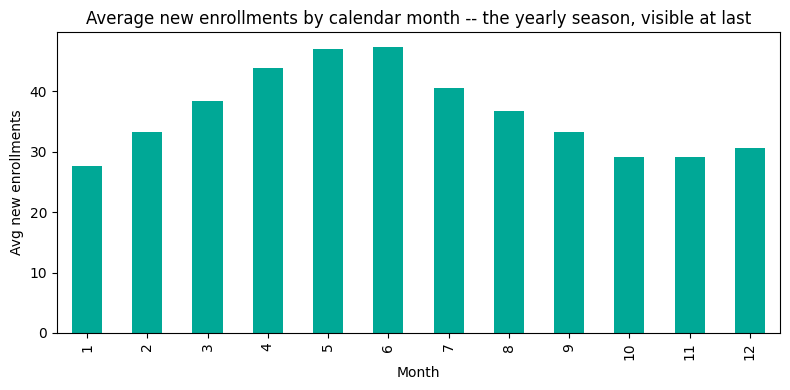

In [9]:
df["day_of_year"] = df["date"].dt.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# quick visual: average enrollments by month shows the yearly seasonal bump
monthly_avg = df.groupby(df["date"].dt.month)["new_enrollments"].mean()
plt.figure(figsize=(8, 4))
monthly_avg.plot(kind="bar", color="#00A896")
plt.title("Average new enrollments by calendar month -- the yearly season, visible at last")
plt.xlabel("Month"); plt.ylabel("Avg new enrollments")
plt.tight_layout()
plt.show()

## 7. Seasonal decomposition — automatically splitting trend / seasonal / residual

**Why:** rather than manually engineering trend and seasonal features one at a time,
`statsmodels`' `seasonal_decompose` automatically factors the whole series into three additive
(or multiplicative) pieces: **trend**, **seasonal**, and **residual** (leftover noise). This
gives you a fast, principled starting point, and the three components themselves can each
become model features.

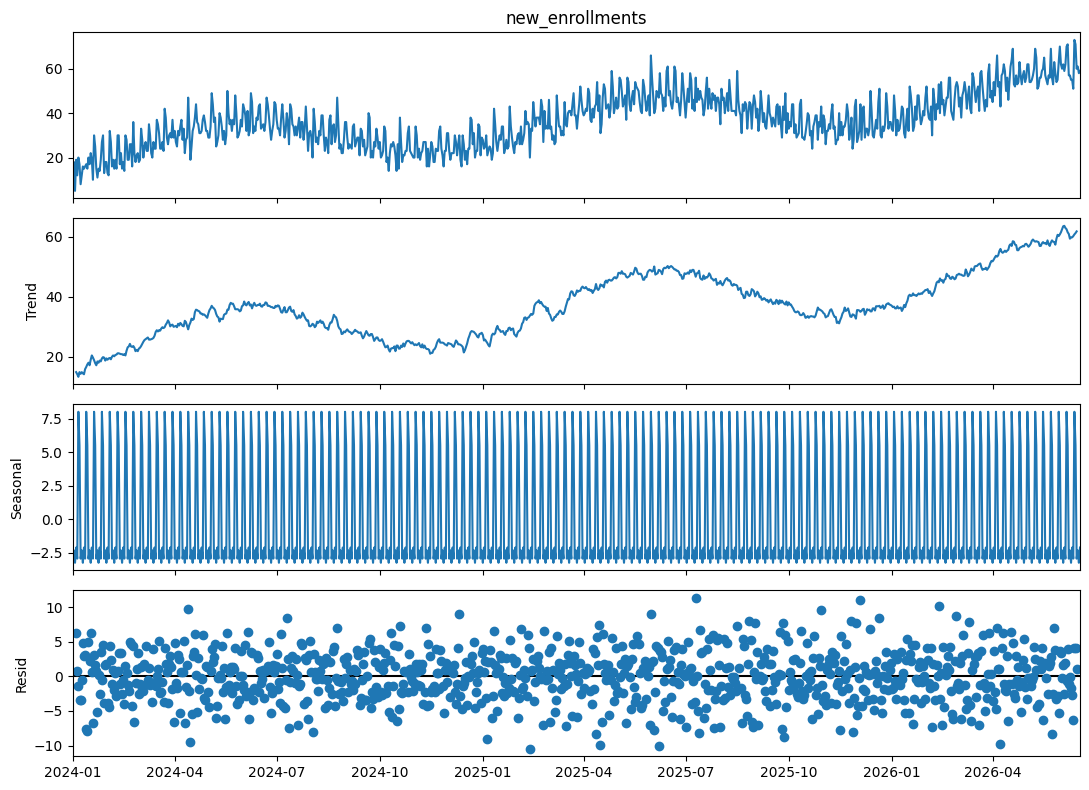

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = df.set_index("date")["new_enrollments"]
decomposition = seasonal_decompose(series, model="additive", period=7)  # period=7 -> weekly cycle

fig = decomposition.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

In [11]:
# The three components can be pulled back into our feature dataframe directly
df["decomp_trend"] = decomposition.trend.values
df["decomp_seasonal"] = decomposition.seasonal.values
df["decomp_residual"] = decomposition.resid.values

df[["date", "new_enrollments", "decomp_trend", "decomp_seasonal", "decomp_residual"]].iloc[10:15]

,date,new_enrollments,decomp_trend,decomp_seasonal,decomp_residual
10,2024-01-11,15,14.142857,-2.110504,2.967646
11,2024-01-12,16,15.857143,-2.936396,3.079254
12,2024-01-13,17,16.571429,8.031237,-7.602666
13,2024-01-14,15,17.428571,5.526773,-7.955345
14,2024-01-15,20,18.000000,-2.939745,4.939745


Notice `decomp_trend` is `NaN` near the very start and end of the series — the decomposition
needs a full window of data on both sides to estimate the trend at any given point, so edges
are unavoidably unobserved (Section 9 covers exactly how to handle NaNs like these).

## 8. Trend features — WHY / WHAT / HOW

**Why:** underneath the weekly/yearly wiggles, is the institute generally growing? A trend
feature isolates that slow-moving direction. `decomp_trend` above is one way; a simple linear
`time_index` fit is another, more explicit way to get an interpretable "units gained per day."

**Manual example (simple approach):** a `time_index` (0, 1, 2, ... for each day) fed to a
linear model directly captures a straight-line trend; its fitted slope is "average enrollments
gained per day."

Estimated trend: 0.0314 extra enrollments per day (~11.4 per year)


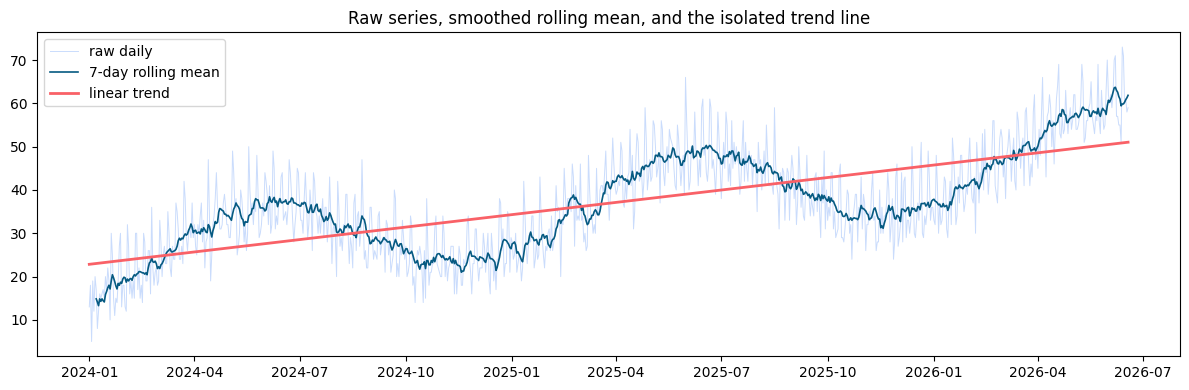

In [12]:
from sklearn.linear_model import LinearRegression

df["time_index"] = np.arange(len(df))
trend_model = LinearRegression().fit(df[["time_index"]], df["new_enrollments"])
print(f"Estimated trend: {trend_model.coef_[0]:.4f} extra enrollments per day "
      f"(~{trend_model.coef_[0]*365:.1f} per year)")

df["trend_component"] = trend_model.predict(df[["time_index"]])

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["new_enrollments"], color="#CADCFC", linewidth=0.7, label="raw daily")
plt.plot(df["date"], df["rolling_mean_7"], color="#065A82", linewidth=1.2, label="7-day rolling mean")
plt.plot(df["date"], df["trend_component"], color="#F96167", linewidth=2, label="linear trend")
plt.legend()
plt.title("Raw series, smoothed rolling mean, and the isolated trend line")
plt.tight_layout()
plt.show()

## 9. Differencing — removing trend directly

**Why:** instead of MODELING the trend (as above), differencing REMOVES it: subtract each
value from the previous one. If a series has a linear trend, differencing once makes it
roughly trend-free (stationary), leaving only the seasonal + noise components — useful for
classical time-series models that assume stationarity (e.g. ARIMA), and as a feature in its
own right ("how much did enrollments change from yesterday?").

**Manual example.** Values `[10, 14, 9, 20]`:
```
diff_1 = [14-10, 9-14, 20-9] = [4, -5, 11]
```

Manual first difference: [4.0, -5.0, 11.0]


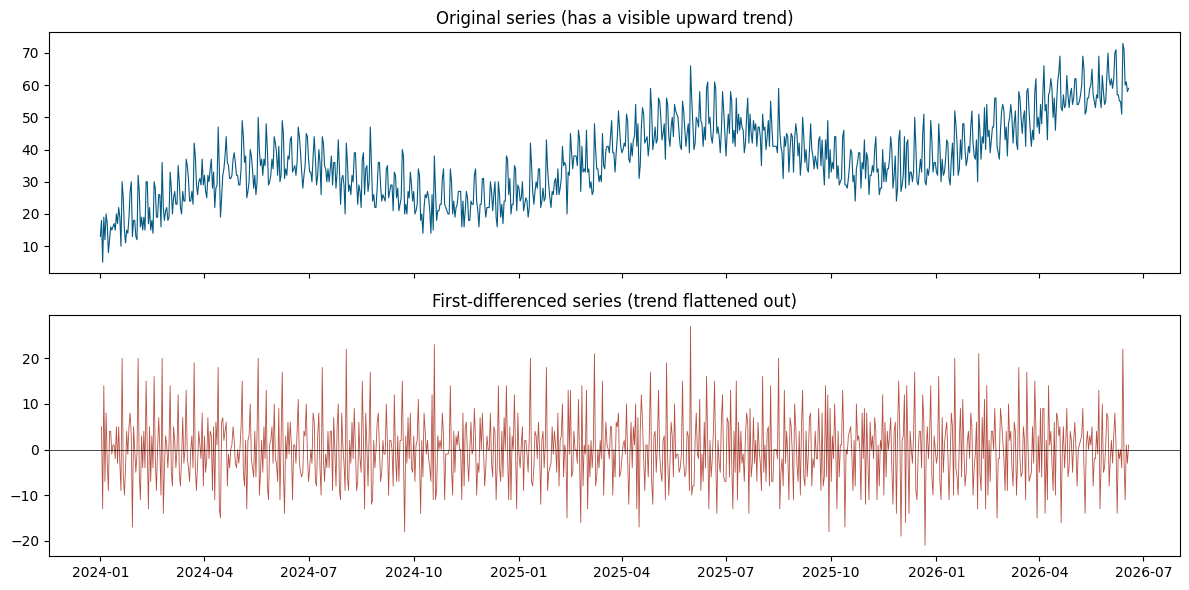

In [13]:
toy_vals = pd.Series([10, 14, 9, 20])
print("Manual first difference:", toy_vals.diff().dropna().tolist())

df["enrollments_diff_1"] = df["new_enrollments"].diff(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df["date"], df["new_enrollments"], color="#065A82", linewidth=0.8)
axes[0].set_title("Original series (has a visible upward trend)")
axes[1].plot(df["date"], df["enrollments_diff_1"], color="#B85042", linewidth=0.6)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("First-differenced series (trend flattened out)")
plt.tight_layout()
plt.show()

## 10. Handling NaNs created by lag / rolling / expanding / differencing features

**Why this matters:** every technique above that looks "backward" necessarily has NO valid
value for the very first few rows (there's no "yesterday" for day 1, no full 7-day window
until day 7). Naively feeding these `NaN`s into a model will error out or silently corrupt
results.

In [14]:
feature_cols_check = ["lag_1", "lag_7", "lag_30", "rolling_mean_7", "expanding_mean",
                       "decomp_trend", "enrollments_diff_1"]
print("Missing values introduced by each time-based feature:")
print(df[feature_cols_check].isna().sum())

Missing values introduced by each time-based feature:
lag_1                  1
lag_7                  7
lag_30                30
rolling_mean_7         6
expanding_mean         0
decomp_trend           6
enrollments_diff_1     1
dtype: int64


**Common strategies, in order of preference:**
1. **Drop the leading rows** — simplest and safest, since there's no real "make-up" value for
   a lag/rolling window that genuinely didn't exist yet. Costs you a small number of rows
   (here, at most 30, from `lag_30` — negligible against 900 days of history).
2. **Backward-fill cautiously** — only defensible for very short gaps, and only if you're
   confident the earliest available value is a reasonable stand-in.
3. **Never mean/median-impute time-based lag/rolling features** the way we did for ordinary
   missing values in Unit 1 — that would fabricate a "recent history" that never happened,
   which is a much stronger assumption than an MCAR imputation.

In [15]:
before_rows = len(df)
df_clean = df.dropna(subset=feature_cols_check).reset_index(drop=True)
print(f"Rows before dropping: {before_rows}")
print(f"Rows after dropping leading NaNs: {len(df_clean)}  (lost {before_rows - len(df_clean)} rows, "
      f"all from the start of the series)")

Rows before dropping: 900
Rows after dropping leading NaNs: 867  (lost 33 rows, all from the start of the series)


## 11. ⚠️ Correct train/test splitting for time series — no shuffling, ever

**Why this is critical:** `sklearn.train_test_split(..., shuffle=True)` (the default) randomly
scatters rows between train and test. For time series, this is a serious leakage bug: a lag/
rolling feature for a "test" row might be computed from a day that's now sitting in "train,"
and — worse — a row in your TRAINING set could end up chronologically AFTER a row in your test
set, meaning the model implicitly learns from the future to predict the past.

**The fix:** always split chronologically — train on the earlier period, test on the later
period, preserving time order exactly as it occurred.

In [16]:
# WRONG for time series (shown for contrast only -- do not use this pattern here)
from sklearn.model_selection import train_test_split
wrong_train, wrong_test = train_test_split(df_clean, test_size=0.2, shuffle=True, random_state=0)
print("Shuffled split -- test set dates are scattered throughout the whole timeline:")
print(sorted(wrong_test['date'].dt.strftime('%Y-%m-%d'))[:5], "...")

# RIGHT for time series: chronological split, no shuffling
split_point = int(len(df_clean) * 0.8)
train_ts = df_clean.iloc[:split_point]
test_ts = df_clean.iloc[split_point:]

print(f"\nChronological split:")
print(f"Train: {train_ts['date'].min().date()} to {train_ts['date'].max().date()} ({len(train_ts)} rows)")
print(f"Test:  {test_ts['date'].min().date()} to {test_ts['date'].max().date()} ({len(test_ts)} rows)")
print("Every train date is strictly before every test date -- no future information leaks backward.")

Shuffled split -- test set dates are scattered throughout the whole timeline:
['2024-02-01', '2024-02-05', '2024-02-08', '2024-02-14', '2024-02-27'] ...

Chronological split:
Train: 2024-01-31 to 2025-12-23 (693 rows)
Test:  2025-12-24 to 2026-06-15 (174 rows)
Every train date is strictly before every test date -- no future information leaks backward.


In [17]:
# For cross-validation on time series, sklearn provides TimeSeriesSplit --
# each fold's training data is always strictly BEFORE its validation data.
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)
for fold, (train_idx, val_idx) in enumerate(tscv.split(df_clean), 1):
    tr_range = (df_clean.iloc[train_idx[0]]['date'].date(), df_clean.iloc[train_idx[-1]]['date'].date())
    val_range = (df_clean.iloc[val_idx[0]]['date'].date(), df_clean.iloc[val_idx[-1]]['date'].date())
    print(f"Fold {fold}: train {tr_range[0]} -> {tr_range[1]}   |   validate {val_range[0]} -> {val_range[1]}")

Fold 1: train 2024-01-31 -> 2024-07-23   |   validate 2024-07-24 -> 2025-01-12
Fold 2: train 2024-01-31 -> 2025-01-12   |   validate 2025-01-13 -> 2025-07-04
Fold 3: train 2024-01-31 -> 2025-07-04   |   validate 2025-07-05 -> 2025-12-24
Fold 4: train 2024-01-31 -> 2025-12-24   |   validate 2025-12-25 -> 2026-06-15


## 12. Putting it together — a feature-ready row

After this session, one row of modeling-ready data looks like this (rows with leading NaNs
already dropped in Section 10).

In [18]:
feature_cols = ["date", "new_enrollments", "lag_1", "lag_7", "lag_30", "rolling_mean_7",
                "rolling_median_7", "rolling_std_7", "expanding_mean", "dow_sin", "dow_cos",
                "doy_sin", "doy_cos", "time_index", "enrollments_diff_1"]
df_clean[feature_cols].iloc[5:10]

,date,new_enrollments,lag_1,lag_7,lag_30,rolling_mean_7,rolling_median_7,rolling_std_7,expanding_mean,dow_sin,dow_cos,doy_sin,doy_cos,time_index,enrollments_diff_1
5,2024-02-05,16,27.0,13.0,20.0,19.428571,18.0,7.390470,17.388889,0.000000,1.000000,0.580800,0.814046,35,-11.0
6,2024-02-06,19,16.0,18.0,17.0,19.571429,18.0,7.367884,17.432432,0.781831,0.623490,0.594727,0.803928,36,3.0
7,2024-02-07,15,19.0,18.0,8.0,19.142857,16.0,7.559289,17.368421,0.974928,-0.222521,0.608477,0.793572,37,-4.0
8,2024-02-08,19,15.0,13.0,12.0,20.000000,19.0,7.071068,17.410256,0.433884,-0.900969,0.622047,0.782980,38,4.0
9,2024-02-09,15,19.0,12.0,16.0,20.428571,19.0,6.579188,17.350000,-0.433884,-0.900969,0.635432,0.772157,39,-4.0


## 13. Recap

- **Lag** = yesterday / last week / last month as a predictor of today — check correlation to
  decide which lags are worth keeping.
- **Rolling mean/std/min/max/median** = five different lenses on "recently," each robust to
  different kinds of noise (median especially resists single extreme values).
- **Expanding window** = an all-time running statistic, stabilizes with more history.
- **Cyclical (sin/cos) encoding** = wraps periodic time (day-of-week, day-of-year) onto a
  circle so "end" and "start" of the cycle sit next to each other.
- **Seasonality** = repeating calendar patterns (weekly, yearly); `seasonal_decompose`
  automates splitting a series into trend + seasonal + residual.
- **Trend** = the slow-moving long-term direction, isolated from noise and seasonality, either
  by fitting a line or reading it off a decomposition.
- **Differencing** = subtracting the previous value removes trend directly, without modeling it.
- Lag/rolling/expanding/differencing ALWAYS create leading `NaN`s — drop them, don't impute
  them like ordinary missing values.
- **Never shuffle a time series train/test split** — always split (and cross-validate)
  chronologically, with `TimeSeriesSplit` or an explicit date cutoff.

**ELI5 recap:** yesterday's page (lag), last week's average/best/worst/typical day (rolling),
your whole diary's average (expanding), a clock face instead of a number line for repeating
time (cyclical), Halloween/birthday spikes (seasonality), a machine that sorts your diary into
three neat piles (decomposition), slowly eating more candies as you grow (trend), writing down
the CHANGE instead of the total (differencing), and never peeking at tomorrow's page to guess
today's number (correct train/test splitting).